# Compare values of n_alpha found using different solution methods


## Compare all 3 methods for a single point

In [1]:
# Reload Process each time (keep editable install up-to-date)
%load_ext autoreload
%autoreload 2
from IPython.display import clear_output
from process.main import SingleRun
import process.data_structure
import process.impurity_radiation as impurity_radiation
import process.constraints
import process.physics
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.colors
import pandas as pd
import seaborn as sns
from process.io.plot_solutions import (
    RunMetadata,
    plot_mfile_solutions,
    plot_mfile_solutions_constraints,
)
from pathlib import Path

Running scipy's SLSQP


In [2]:
# Common process set up
input_file = "data/lt_tau_alpha_sol_eval_IN.DAT"
single_run = SingleRun(input_file)
process.data_structure.impurity_radiation_module.f_nd_impurity_electron_array[13] = (
    5.0e-6
)
process.data_structure.current_drive_variables.p_hcd_primary_extra_heat_mw = 200.0
impurity_radiation.rho_fix = True
process.data_structure.impurity_radiation_module.f_p_plasma_core_rad_reduction = 1.0
impurity_radiation.int_edge_rad = True
process.data_structure.physics_variables.i_rad_loss = 0
process.physics.old_n_alpha_calc = False
process.physics.current_n_alpha_calc = False
process.physics.mattis_test = False
process.physics.eval_count = 0

# Study set up
N = 1
ne = np.linspace(7.0e19, 7.0e20, num=N)
te = np.linspace(10.0, 10.0, num=N)
ne_grid, te_grid = np.meshgrid(ne, te)


# Evaluation func
def eval_n_alpha(ne, te):
    single_run = SingleRun(input_file)
    process.data_structure.physics_variables.dene = ne
    process.data_structure.physics_variables.te = te
    process.physics.eval_count = 0

    try:
        # Handle failed runs
        single_run.run()
    except Exception as e:
        # return None, None, None, None, None
        raise e

    return (
        process.constraints.constraint_equation_2().normalised_residual,
        process.constraints.constraint_equation_62().normalised_residual,
        process.data_structure.physics_variables.nd_alphas,
        process.data_structure.physics_variables.t_alpha_confinement,
        process.data_structure.physics_variables.t_energy_confinement,
    )


def make_df(con2, con62, nd_alphas, tau_alpha, tau_E):
    return pd.DataFrame(
        {
            "ne": ne_grid.flatten(),
            "te": te_grid.flatten(),
            "ppb_con": con2.flatten(),
            "tau_alpha_con": con62.flatten(),
            "nd_alphas": nd_alphas.flatten(),
            "tau_alpha": tau_alpha.flatten(),
            "tau_E": tau_E.flatten(),
        }
    )


eval_n_alpha_vec = np.vectorize(pyfunc=eval_n_alpha)
clear_output()


In [7]:
# Original: solve for n_alpha to make tau_alpha / tau_E = 5
# input_file = "data/lt_tau_alpha_sol_solve_n_alpha_IN.DAT"
# process.physics.old_n_alpha_calc = True
# process.physics.current_n_alpha_calc = False
# con2, con62, nd_alphas_original, tau_alpha, tau_E = eval_n_alpha_vec(ne_grid, te_grid)
# clear_output()

# # Current: calculate n_alpha from tau_alpha / tau_E = 5
# # get negative znfuel at ne = 9e19, use 7e19 instead
# input_file = "data/lt_tau_alpha_sol_eval_IN.DAT"
# process.physics.old_n_alpha_calc = False
# process.physics.current_n_alpha_calc = True
# con2, con62, nd_alphas_current, tau_alpha, tau_E = eval_n_alpha_vec(ne_grid, te_grid)
# clear_output()

# New: Matti's equation
input_file = "data/lt_tau_alpha_sol_eval_IN.DAT"
process.physics.old_n_alpha_calc = False
process.physics.current_n_alpha_calc = False
con2, con62, nd_alphas_new, tau_alpha, tau_E = eval_n_alpha_vec(ne_grid, te_grid)
clear_output()

# print(f"{nd_alphas_original = }")
# print(f"{nd_alphas_current = }")
print(f"{nd_alphas_new = }")

nd_alphas_new = array([[9.87180327e+14]])


The original and current methods of n_alpha calculation result in the same values as they both use tau_alpha / tau_E = 5, the former as a constraint and the latter in the plasma composition model itself. Matti's new equation results in drastically different results. It should be noted that this is not enforcing the tau_alpha / tau_E = 5 constraint in the last case.

Try multiplying the density profile with the reactivity before performing the integral.

## Solve for n_alpha to make tau_alpha / tau_E = 5
The original way of finding n_alpha, but now fixed as an equality.

In [ ]:
N = 8
ne = np.linspace(7.0e19, 1.0e20, num=N)
te = np.linspace(7.0, 12.0, num=N)
ne_grid, te_grid = np.meshgrid(ne, te)

input_file = "data/lt_tau_alpha_sol_solve_n_alpha_IN.DAT"
process.physics.old_n_alpha_calc = True
process.physics.current_n_alpha_calc = False

con2, con62, nd_alphas, tau_alpha, tau_E = eval_n_alpha_vec(ne_grid, te_grid)
clear_output()
make_df(con2, con62, nd_alphas, tau_alpha, tau_E)


,ne,te,ppb_con,tau_alpha_con,nd_alphas,tau_alpha,tau_E
0,4.000000e+19,7.0,0.354167,3.330669e-16,2.009329e+17,15.105871,3.021174
1,5.333333e+19,7.0,0.121318,1.110223e-16,6.960047e+17,23.590819,4.718164
2,6.666667e+19,7.0,NaN,NaN,NaN,NaN,NaN
3,8.000000e+19,7.0,NaN,NaN,NaN,NaN,NaN
4,9.333333e+19,7.0,NaN,NaN,NaN,NaN,NaN
5,1.066667e+20,7.0,NaN,NaN,NaN,NaN,NaN
6,1.200000e+20,7.0,NaN,NaN,NaN,NaN,NaN
7,4.000000e+19,8.5,0.296161,-6.661338e-16,2.979040e+17,14.485853,2.897171
8,5.333333e+19,8.5,0.105317,3.330669e-16,9.773532e+17,19.412615,3.882523
9,6.666667e+19,8.5,-0.037242,2.220446e-16,2.984820e+18,33.342155,6.668431


/tmp/ipykernel_384543/244005275.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Text(0.5, 1.0, '$n_\\alpha$ against $n_e$ and $T_e$')

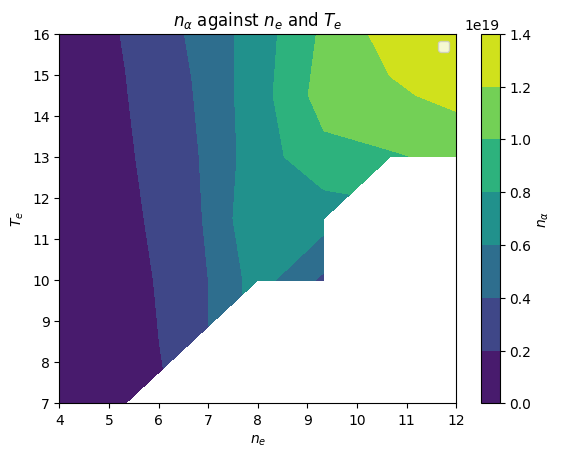

In [4]:
%matplotlib inline
# n_alphas
fig, ax = plt.subplots()
# Log colourbar
contour = ax.contourf(
    (ne_grid * 1e-19),
    te_grid,
    nd_alphas,
    # locator=matplotlib.ticker.LogLocator(),
)
fig.colorbar(contour, ax=ax, label=r"$n_\alpha$")
ax.set_xlabel("$n_e$")
ax.set_ylabel("$T_e$")
ax.legend()
# ax.scatter(ne_grid, te_grid)
# ax.set_xlim(3e19,8e19)
ax.set_title(r"$n_\alpha$ against $n_e$ and $T_e$")

Some missing values, but generally > 1e18.

## Calculate n_alpha from tau_alpha / tau_E = 5
Use current calculation for n_alpha using tau_alpha / tau_E = 5 relation, but evaluate only.

In [5]:
input_file = "data/lt_tau_alpha_sol_eval_IN.DAT"
process.physics.old_n_alpha_calc = False
process.physics.current_n_alpha_calc = True

con2, con62, nd_alphas, tau_alpha, tau_E = eval_n_alpha_vec(ne_grid, te_grid)
clear_output()
make_df(con2, con62, nd_alphas, tau_alpha, tau_E)


,ne,te,ppb_con,tau_alpha_con,nd_alphas,tau_alpha,tau_E
0,4.000000e+19,7.0,0.354167,2.207723e-11,2.009329e+17,15.105871,3.021174
1,5.333333e+19,7.0,0.121318,3.073430e-12,6.960047e+17,23.590819,4.718164
2,6.666667e+19,7.0,NaN,NaN,NaN,NaN,NaN
3,8.000000e+19,7.0,NaN,NaN,NaN,NaN,NaN
4,9.333333e+19,7.0,NaN,NaN,NaN,NaN,NaN
5,1.066667e+20,7.0,NaN,NaN,NaN,NaN,NaN
6,1.200000e+20,7.0,NaN,NaN,NaN,NaN,NaN
7,4.000000e+19,8.5,0.296161,1.907970e-10,2.979040e+17,14.485853,2.897171
8,5.333333e+19,8.5,0.105317,2.278688e-11,9.773532e+17,19.412615,3.882523
9,6.666667e+19,8.5,-0.037242,2.101652e-13,2.984820e+18,33.342155,6.668431


/tmp/ipykernel_384543/244005275.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Text(0.5, 1.0, '$n_\\alpha$ against $n_e$ and $T_e$')

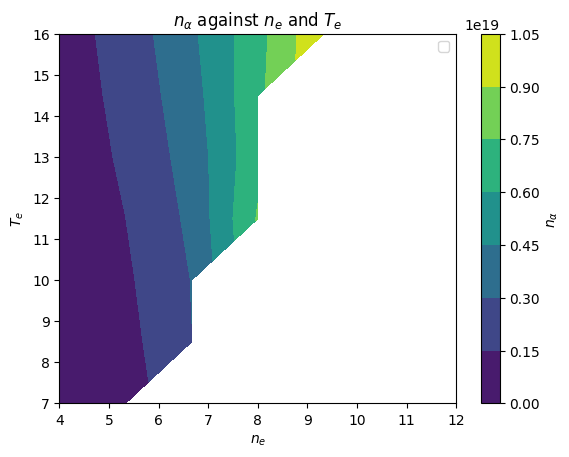

In [6]:
%matplotlib inline
# n_alphas
fig, ax = plt.subplots()
# Log colourbar
contour = ax.contourf(
    (ne_grid * 1e-19),
    te_grid,
    nd_alphas,
    # locator=matplotlib.ticker.LogLocator(),
)
fig.colorbar(contour, ax=ax, label=r"$n_\alpha$")
ax.set_xlabel("$n_e$")
ax.set_ylabel("$T_e$")
ax.legend()
# ax.scatter(ne_grid, te_grid)
# ax.set_xlim(3e19,8e19)
ax.set_title(r"$n_\alpha$ against $n_e$ and $T_e$")

Similar structure, but more missing values. Probably due to tau_alpha / tau_E = 5 not being solved for, but used in calculation of n_alpha.

## Matti's equation

In [14]:
input_file = "data/lt_tau_alpha_sol_eval_IN.DAT"
process.physics.old_n_alpha_calc = False
process.physics.current_n_alpha_calc = False
con2, con62, nd_alphas, tau_alpha, tau_E = eval_n_alpha_vec(ne_grid, te_grid)
clear_output()
quad_sol_df = make_df(con2, con62, nd_alphas, tau_alpha, tau_E)
quad_sol_df

,ne,te,ppb_con,tau_alpha_con,nd_alphas,tau_alpha,tau_E
0,9.000000e+19,9.0,-0.048115,0.999977,7.968661e+14,0.002673,23.071158
1,9.066667e+19,9.0,-0.041565,0.999981,8.010708e+14,0.002633,28.289135
2,9.133333e+19,9.0,-0.033258,0.999986,8.052581e+14,0.002595,37.860849
3,9.200000e+19,9.0,-0.021782,0.999992,8.094280e+14,0.002558,63.436313
4,9.266667e+19,9.0,-0.000969,1.000000,8.135808e+14,0.002522,17122.601466
...,...,...,...,...,...,...,...
251,9.733333e+19,12.0,-0.140459,0.999923,7.396306e+14,0.001078,2.786428
252,9.800000e+19,12.0,-0.140346,0.999923,7.430931e+14,0.001063,2.769746
253,9.866667e+19,12.0,-0.140231,0.999924,7.465410e+14,0.001049,2.753205
254,9.933333e+19,12.0,-0.140112,0.999924,7.499745e+14,0.001035,2.736805


/tmp/ipykernel_1358378/4107039025.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[[7.96866116e+14 8.01070790e+14 8.05258060e+14 8.09428033e+14
  8.13580821e+14 8.17716529e+14 8.21835266e+14 8.25937138e+14
  8.30022250e+14 8.34090705e+14 8.38142608e+14 8.42178061e+14
  8.46197165e+14 8.50200022e+14 8.54186730e+14 8.58157390e+14]
 [7.71021357e+14 7.75083780e+14 7.79129328e+14 7.83158106e+14
  7.87170221e+14 7.91165778e+14 7.95144880e+14 7.99107631e+14
  8.03054134e+14 8.06984489e+14 8.10898797e+14 8.14797159e+14
  8.18679672e+14 8.22546435e+14 8.26397545e+14 8.30233098e+14]
 [7.46457584e+14 7.50385013e+14 7.54296070e+14 7.58190860e+14
  7.62069484e+14 7.65932046e+14 7.69778647e+14 7.73609387e+14
  7.77424365e+14 7.81223681e+14 7.85007433e+14 7.88775716e+14
  7.92528628e+14 7.96266265e+14 7.99988719e+14 8.03696086e+14]
 [7.22548135e+14 7.26344364e+14 7.30124714e+14 7.33889284e+14
  7.37638176e+14 7.41371490e+14 7.45089323e+14 7.48791774e+14
  7.52478939e+14 7.56150915e+14 7.59807796e+14 7.63449678e+14
  7.67076653e+14 7.70688815e+14 7.74286256e+14 7.77869066e+14]
 [9.

Text(0.5, 1.0, '$n_\\alpha$ against $n_e$ and $T_e$')

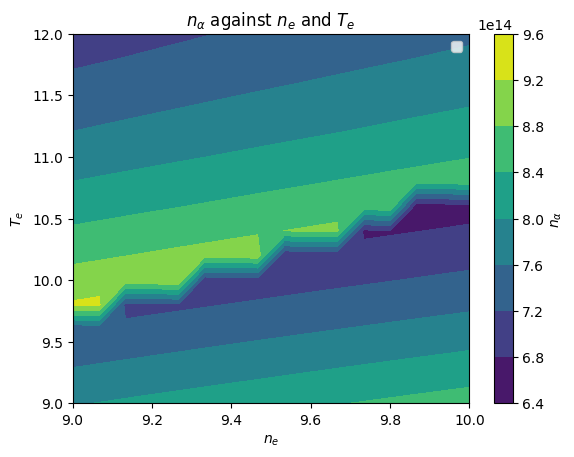

In [15]:
%matplotlib inline
fig, ax = plt.subplots()
print(nd_alphas)
# nd_alphas[nd_alphas == 1.0e19] = 0.0
# nd_alphas = np.array(nd_alphas, dtype=float)
contour = ax.contourf(
    (ne_grid * 1e-19),
    te_grid,
    nd_alphas,
    # locator=matplotlib.ticker.LogLocator(),
)
fig.colorbar(contour, ax=ax, label=r"$n_\alpha$")
ax.set_xlabel("$n_e$")
ax.set_ylabel("$T_e$")
ax.legend()
# ax.scatter(ne_grid, te_grid)
# ax.set_xlim(3e19,8e19)
ax.set_title(r"$n_\alpha$ against $n_e$ and $T_e$")